In [11]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

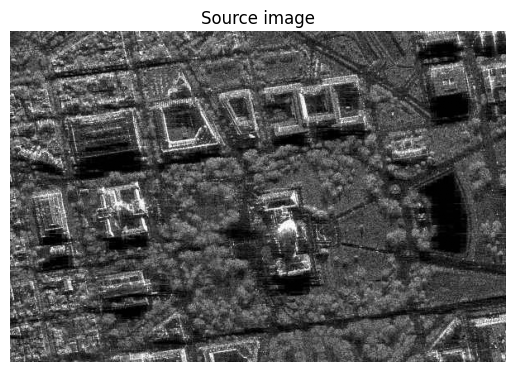

In [12]:
# 1. Загрузите изображение в оттенках серого sar_1_gray.jpg.

img = cv2.imread('sar_1_gray.jpg', cv2.IMREAD_GRAYSCALE)

plt.imshow(img, cmap='gray')
plt.title("Source image")
plt.axis('off')
plt.show()

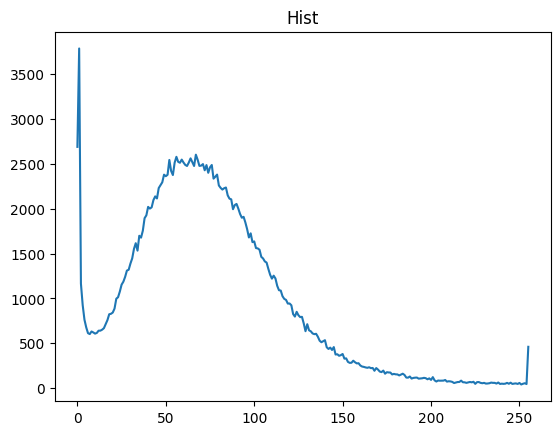

In [13]:
# 2. постройте гистограмму

histSize = 256 # кол-во столбиков (бинов)
histRange = (0, 256) # диапозон яркостей

# строим гистограмму используя функцию opencv 
hist = cv2.calcHist([img], [0], None, [histSize], histRange)

plt.title("Hist")
plt.plot(hist)

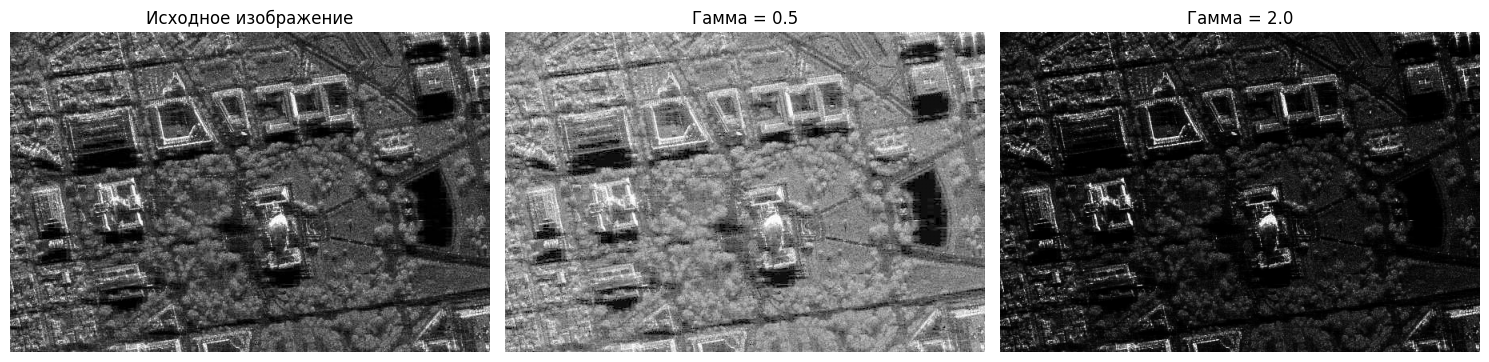

In [14]:
# 3. реализуйте алгоритм гамма коррекции с параметром гамма <1, >1.

def apply_gamma(image, gamma_value):
    # Переводим изображение в формат с плавающей точкой
    img_float = image.astype(np.float32) / 255.0

    # Применяем степенное преобразование
    gamma_img = np.clip(img_float ** gamma_value, 0, 1)

    # Масштабируем обратно в диапазон [0, 255]
    result = (gamma_img * 255).astype(np.uint8)

    return result


# Примеры применения
gamma_less_1  = apply_gamma(img, 0.5)   # гамма < 1 — осветление
gamma_greater_1 = apply_gamma(img, 2.0) # гамма > 1 — затемнение

# Визуализация
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

titles = ["Исходное изображение", "Гамма = 0.5", "Гамма = 2.0"]
images = [img, gamma_less_1, gamma_greater_1]

for ax, image_data, title in zip(axes, images, titles):
    ax.imshow(image_data, cmap='gray')
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()


In [15]:
# 4. Сравните исходное изображение, скорректированное при помощи гамма-фильтра. MSE, SSIM.

from math import sqrt

def mse(img1, img2):
    return np.mean((img1.astype("float") - img2.astype("float")) ** 2)

# Простая реализация SSIM для grayscale
def ssim(img1, img2):
    C1 = (0.01 * 255)**2
    C2 = (0.03 * 255)**2

    img1 = img1.astype(np.float64)
    img2 = img2.astype(np.float64)

    mu1 = cv2.GaussianBlur(img1, (11,11), 1.5)
    mu2 = cv2.GaussianBlur(img2, (11,11), 1.5)

    sigma1_sq = cv2.GaussianBlur(img1*img1, (11,11), 1.5) - mu1**2
    sigma2_sq = cv2.GaussianBlur(img2*img2, (11,11), 1.5) - mu2**2
    sigma12   = cv2.GaussianBlur(img1*img2, (11,11), 1.5) - mu1*mu2

    ssim_map = ((2*mu1*mu2 + C1) * (2*sigma12 + C2)) / ((mu1**2 + mu2**2 + C1) * (sigma1_sq + sigma2_sq + C2))
    return ssim_map.mean()

print("Gamma 0.5 -> MSE:", mse(img, img_gamma_low), "SSIM:", ssim(img, img_gamma_low))
print("Gamma 2.0 -> MSE:", mse(img, img_gamma_high), "SSIM:", ssim(img, img_gamma_high))






Gamma 0.5 -> MSE: 3250.429145833333 SSIM: 0.7826855938698241
Gamma 2.0 -> MSE: 2383.7636375 SSIM: 0.5193678832134501


In [16]:
# 4. Сравните исходное изображение, скорректированное при помощи гамма-фильтра. MSE, SSIM.

from skimage.metrics import structural_similarity, mean_squared_error

(ssim, diff) = structural_similarity(img, img_gamma_high, full=True)
diff = (diff * 255).astype("uint8")

mse = mean_squared_error(img, img_gamma_high)

print(f"SSIM: {ssim}")
print(f"MSE: {mse}")


SSIM: 0.5270459922820344
MSE: 2383.7636375


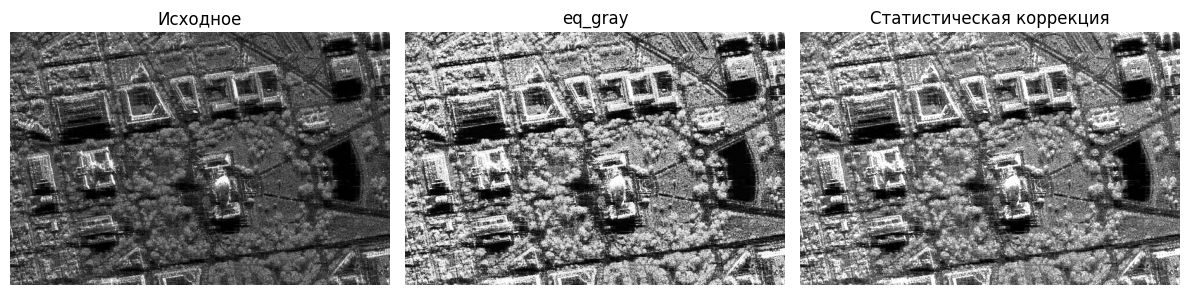

In [19]:
# 5. реализуйте алгоритм статистической цветокоррекции на основе статистики eq_gray.


def apply_stat_correction(image):
    # Вычисляем гистограмму и кумулятивное распределение
    hist_values, bin_edges = np.histogram(image.ravel(), 256, [0, 256])
    cdf = hist_values.cumsum()

    # Избегаем деления на ноль
    cdf_masked = np.ma.masked_equal(cdf, 0)
    cdf_scaled = (cdf_masked - cdf_masked.min()) * 255 / (cdf_masked.max() - cdf_masked.min())
    cdf_final = np.ma.filled(cdf_scaled, 0).astype(np.uint8)

    # Применяем преобразование
    equalized = cdf_final[image]
    return equalized


# сравниваем статистику исходного и эталонного изображений
equalized_gray = cv2.equalizeHist(img)

mean_original, std_original = img.mean(), img.std()
mean_equalized, std_equalized = equalized_gray.mean(), equalized_gray.std()

stat_adjusted = (img.astype(np.float32) - mean_original) * (std_equalized / std_original) + mean_equalized
stat_adjusted = np.clip(stat_adjusted, 0, 255).astype(np.uint8)

# визуализация
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
titles = ["Исходное", "eq_gray", "Статистическая коррекция"]
images = [img, equalized_gray, stat_adjusted]

for ax, im, title in zip(axes, images, titles):
    ax.imshow(im, cmap='gray')
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()



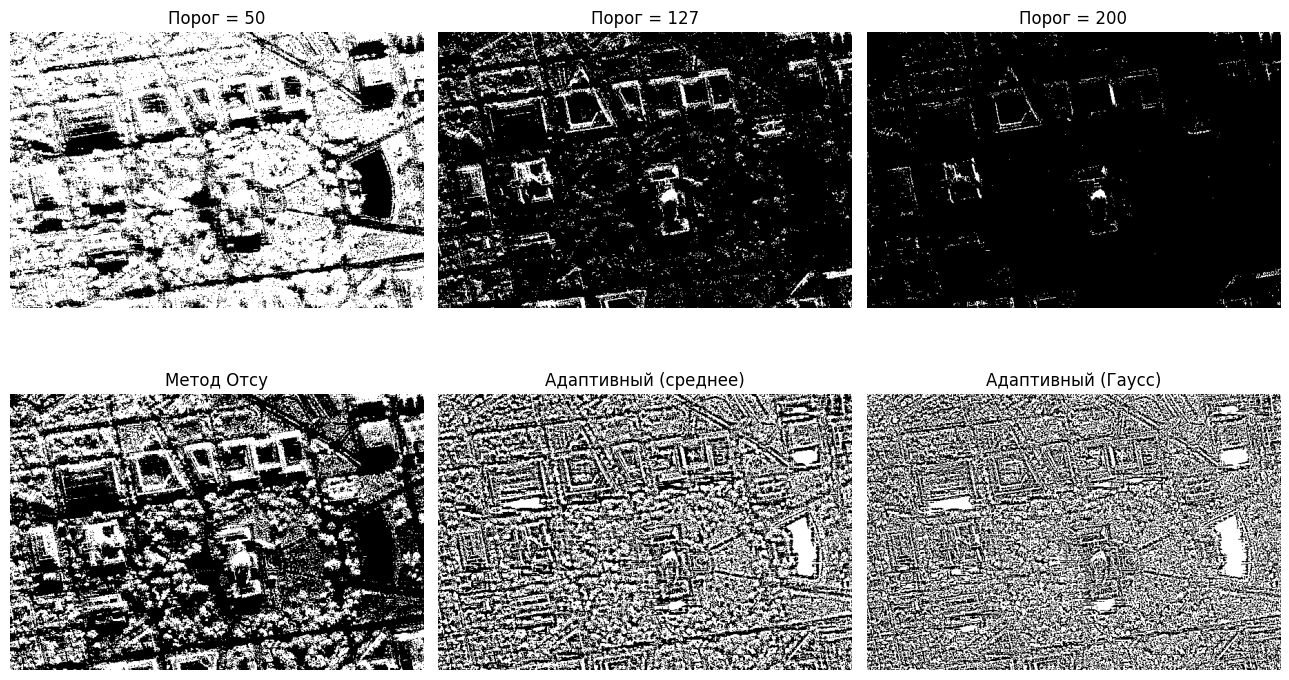

In [20]:
# 6. Протестируйте работу алгоритмов пороговой фильтрации с различными параметрами.

# --- Пороговая фильтрация изображения ---

# Глобальные пороги
t50  = cv2.threshold(img, 50, 255, cv2.THRESH_BINARY)[1]
t127 = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)[1]
t200 = cv2.threshold(img, 200, 255, cv2.THRESH_BINARY)[1]

# Метод Отсу (автоматический порог)
otsu_thresh = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)[1]

# Адаптивные методы
adapt_mean   = cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
                                     cv2.THRESH_BINARY, blockSize=11, C=5)
adapt_gauss  = cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                     cv2.THRESH_BINARY, blockSize=11, C=5)

# --- Визуализация результатов ---
thresholds = [t50, t127, t200, otsu_thresh, adapt_mean, adapt_gauss]
titles = [
    "Порог = 50",
    "Порог = 127",
    "Порог = 200",
    "Метод Отсу",
    "Адаптивный (среднее)",
    "Адаптивный (Гаусс)"
]

fig, axes = plt.subplots(2, 3, figsize=(13, 8))

for ax, img_th, title in zip(axes.ravel(), thresholds, titles):
    ax.imshow(img_th, cmap='gray')
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

